# Movie Review Sentiment Analysis
 
## Problem
Reading thousands of movie reviews by hand doesn't scale. This project **automatically classifies a review as positive or negative** from its text alone, a supervised **binary text classification** task.
 
## Dataset
IMDB 50K Movie Reviews (Kaggle: `lakshmi25npathi/imdb-dataset-of-50k-movie-reviews`)
 
| Property | Detail |
|---|---|
| Reviews | 50,000 |
| Columns | `review` (text), `sentiment` (label) |
| Balance | 25,000 positive / 25,000 negative |
| Missing | None |
| Duplicates | 418 (removed) |
 
Balanced classes keep accuracy trustworthy, and 50K examples give the models plenty to learn from.

## Exploratory Data Analysis


In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import kagglehub
from sklearn.model_selection import train_test_split
from collections import Counter
from wordcloud import WordCloud
import re
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize
import contractions
from bs4 import BeautifulSoup
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize
from sklearn.metrics import accuracy_score,recall_score, classification_report, confusion_matrix,recall_score,precision_score, f1_score
#logistic regression,SVM,Naive Bayes,Random Forest and MultinomialNB 
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import RidgeClassifier

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\GRACE\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\GRACE\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\GRACE\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
!pip install wordcloud
!pip install nltk contractions beautifulsoup4 wordcloud

In [4]:
data = kagglehub.dataset_download('lakshmi25npathi/imdb-dataset-of-50k-movie-reviews')
print('data is downloaded successfully')

data is downloaded successfully


In [5]:
df = pd.read_csv(data + '/IMDB Dataset.csv')

In [82]:
#checking the first 10 rows of the dataset/
df.head(10)

,review,sentiment,word_count,char_count
0,One of the other reviewers has mentioned that ...,positive,307,1761
1,A wonderful little production. <br /><br />The...,positive,162,998
2,I thought this was a wonderful way to spend ti...,positive,166,926
3,Basically there's a family where a little boy ...,negative,138,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230,1317
5,"Probably my all-time favorite movie, a story o...",positive,119,656
6,I sure would like to see a resurrection of a u...,positive,150,726
7,"This show was an amazing, fresh & innovative i...",negative,174,934
8,Encouraged by the positive comments about this...,negative,130,681
9,If you like original gut wrenching laughter yo...,positive,33,176


In [83]:
#shape of the dataset
df.shape

(50000, 4)

In [84]:
#checking the data types of each column in the dataset
df.dtypes

review        object
sentiment     object
word_count     int64
char_count     int64
dtype: object

In [85]:
#checking the column names of the dataset
df.columns

Index(['review', 'sentiment', 'word_count', 'char_count'], dtype='object')

In [86]:
#value counts of the sentiment column
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [87]:
#checking for duplicate and null values

print('duplicate values:', df.duplicated().sum())

print('null values:', df.isnull().sum())

duplicate values: 418
null values: review        0
sentiment     0
word_count    0
char_count    0
dtype: int64


In [ ]:
#checking the total length of all reviews

print("total review length:", df['review'].str.len().sum())

total review length: 65471551


In [88]:
#checking for missing values

missing_df = pd.DataFrame({'column_name': df.columns, 'missing_values': df.isnull().sum(),
                            'missing_percentage': df.isnull().sum() / len(df) * 100})
print(missing_df)

           column_name  missing_values  missing_percentage
review          review               0                 0.0
sentiment    sentiment               0                 0.0
word_count  word_count               0                 0.0
char_count  char_count               0                 0.0


In [89]:
#duplicate values and percentage of duplicate values in the dataset

duplicate_df =  pd.DataFrame({'column_name': df.columns, 'duplicate_values': df.duplicated().sum(),
                            'duplicate_percentage': df.duplicated().sum() / len(df) * 100})
print(duplicate_df)

  column_name  duplicate_values  duplicate_percentage
0      review               418                 0.836
1   sentiment               418                 0.836
2  word_count               418                 0.836
3  char_count               418                 0.836


In [90]:
#checking for the compatibility of the dataset with the available memory in the system

memory_usage = df.memory_usage(deep=True).sum() / (1024 ** 2)  # Convert to MB
print(memory_usage)


77.73240756988525


In [16]:
df.describe

<bound method NDFrame.describe of                                                   review sentiment
0      One of the other reviewers has mentioned that ...  positive
1      A wonderful little production. <br /><br />The...  positive
2      I thought this was a wonderful way to spend ti...  positive
3      Basically there's a family where a little boy ...  negative
4      Petter Mattei's "Love in the Time of Money" is...  positive
...                                                  ...       ...
49995  I thought this movie did a down right good job...  positive
49996  Bad plot, bad dialogue, bad acting, idiotic di...  negative
49997  I am a Catholic taught in parochial elementary...  negative
49998  I'm going to have to disagree with the previou...  negative
49999  No one expects the Star Trek movies to be high...  negative

[50000 rows x 2 columns]>

In [91]:
print("\nDUPLICATE ANALYSIS:")
print("-"*70)

# Find duplicate rows
duplicates = df[df.duplicated(keep=False)]
print(f'Total duplicate rows: {len(duplicates)}')
print(f'Unique duplicate groups: {df.duplicated().sum()}')

# Show a few duplicates
print('\nSample duplicates:')
print(duplicates.head(4))


DUPLICATE ANALYSIS:
----------------------------------------------------------------------
Total duplicate rows: 824
Unique duplicate groups: 418

Sample duplicates:
                                                review sentiment  word_count  \
42   Of all the films I have seen, this one, The Ra...  negative         176   
84   We brought this film as a joke for a friend, a...  negative          75   
140  Before I begin, let me get something off my ch...  negative         393   
219  Ed Wood rides again. The fact that this movie ...  negative         168   

     char_count  
42          937  
84          402  
140        2267  
219         892  


In [18]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


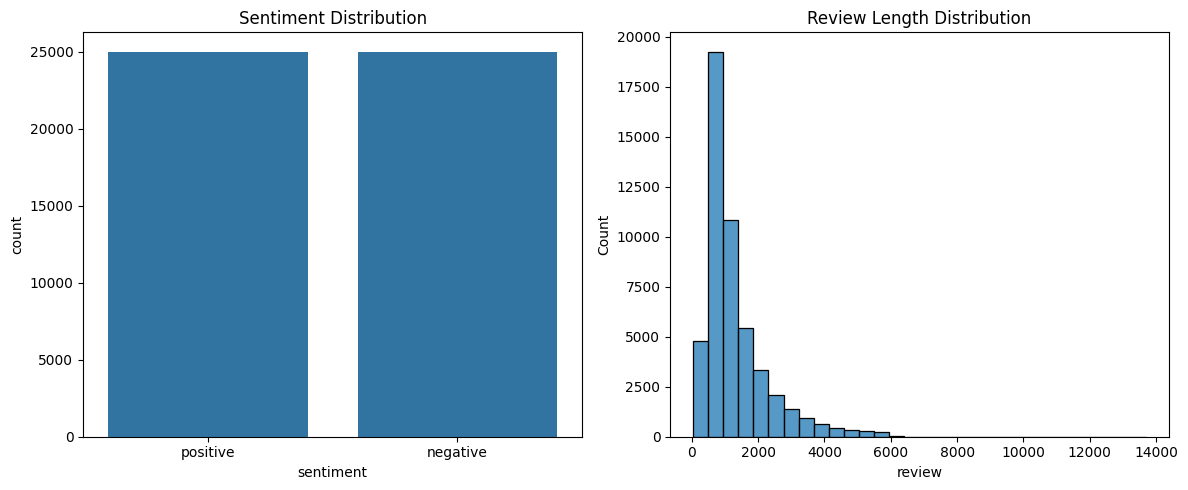

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='sentiment', data=df, ax=axes[0])
axes[0].set_title('Sentiment Distribution')
sns.histplot(df['review'].str.len(), bins=30, ax=axes[1])
axes[1].set_title('Review Length Distribution')
plt.tight_layout()
plt.show() 

In [93]:
#analysing the length of the reviews in the dataset
Empty_review = df[df['review'].str.len() == 0]
print(f'Total empty reviews: {len(Empty_review)}')

Review_length = df['review'].str.len()
print(f'Min review length: {Review_length.min()}')
print(f'Max review length: {Review_length.max()}')
print(f'Average review length: {Review_length.mean()}')

Total empty reviews: 0
Min review length: 32
Max review length: 13704
Average review length: 1309.43102


In [21]:
Review_length.describe()

count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review, dtype: float64

In [94]:
#splitting the reviews into words and counting the number of words and characters in each review
df['word_count'] = df['review'].str.split().apply(len)
df['char_count'] = df['review'].str.len()
print(df[['word_count','char_count']].describe().round(2))

       word_count  char_count
count    50000.00    50000.00
mean       231.16     1309.43
std        171.34      989.73
min          4.00       32.00
25%        126.00      699.00
50%        173.00      970.00
75%        280.00     1590.25
max       2470.00    13704.00


In [23]:
df.head()

,review,sentiment,word_count,char_count
0,One of the other reviewers has mentioned that ...,positive,307,1761
1,A wonderful little production. <br /><br />The...,positive,162,998
2,I thought this was a wonderful way to spend ti...,positive,166,926
3,Basically there's a family where a little boy ...,negative,138,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230,1317


In [24]:
sentiment_counts = df.groupby('sentiment')['word_count'].describe()

In [25]:
sentiment_counts

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,25000.0,229.46456,164.947795,4.0,128.0,174.0,278.0,1522.0
positive,25000.0,232.84932,177.497046,10.0,125.0,172.0,284.0,2470.0



Text EDA Summary: 
Top 10 most common words: [('the', 635766), ('a', 315257), ('and', 313549), ('of', 286598), ('to', 264402), ('is', 204825), ('in', 179158), ('i', 132384), ('this', 131309), ('that', 130096)]
[('the', 635766), ('a', 315257), ('and', 313549), ('of', 286598), ('to', 264402), ('is', 204825), ('in', 179158), ('i', 132384), ('this', 131309), ('that', 130096)]


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'the'),
  Text(1, 0, 'a'),
  Text(2, 0, 'and'),
  Text(3, 0, 'of'),
  Text(4, 0, 'to'),
  Text(5, 0, 'is'),
  Text(6, 0, 'in'),
  Text(7, 0, 'i'),
  Text(8, 0, 'this'),
  Text(9, 0, 'that')])

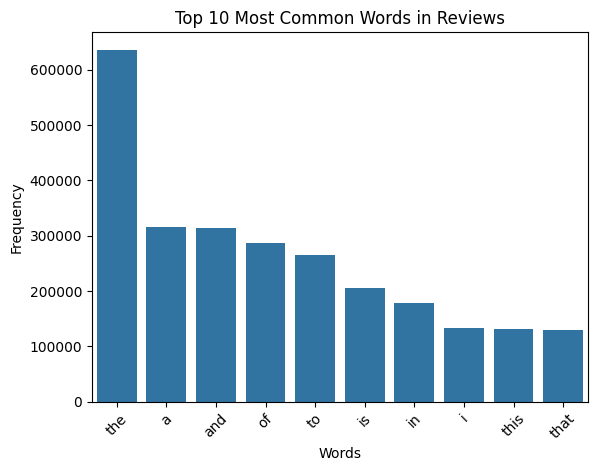

In [26]:
print("="*70)
print("\nText EDA Summary: ")
print("="*70)

review= df['review'].dropna()

all_words = "".join(review).lower().split()
word_freq = Counter(all_words)
print(f'Top 10 most common words: {word_freq.most_common(10)}')
print(word_freq.most_common(10))

sns.barplot(x=[w for w, _ in word_freq.most_common(10)], y=[c for _, c in word_freq.most_common(10)])
plt.title('Top 10 Most Common Words in Reviews')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45) 


TOP 20 MOST FREQUENT WORDS (ALL DATA):
----------------------------------------------------------------------
 1. the             | 635,766
 2. a               | 315,257
 3. and             | 313,549
 4. of              | 286,598
 5. to              | 264,402
 6. is              | 204,825
 7. in              | 179,158
 8. i               | 132,384
 9. this            | 131,309
10. that            | 130,096
11. it              | 129,013
12. /><br           | 100,979
13. was             | 93,232
14. as              | 87,679
15. with            | 84,455
16. for             | 84,197
17. but             | 77,832
18. on              | 62,807
19. movie           | 61,431
20. are             | 56,996


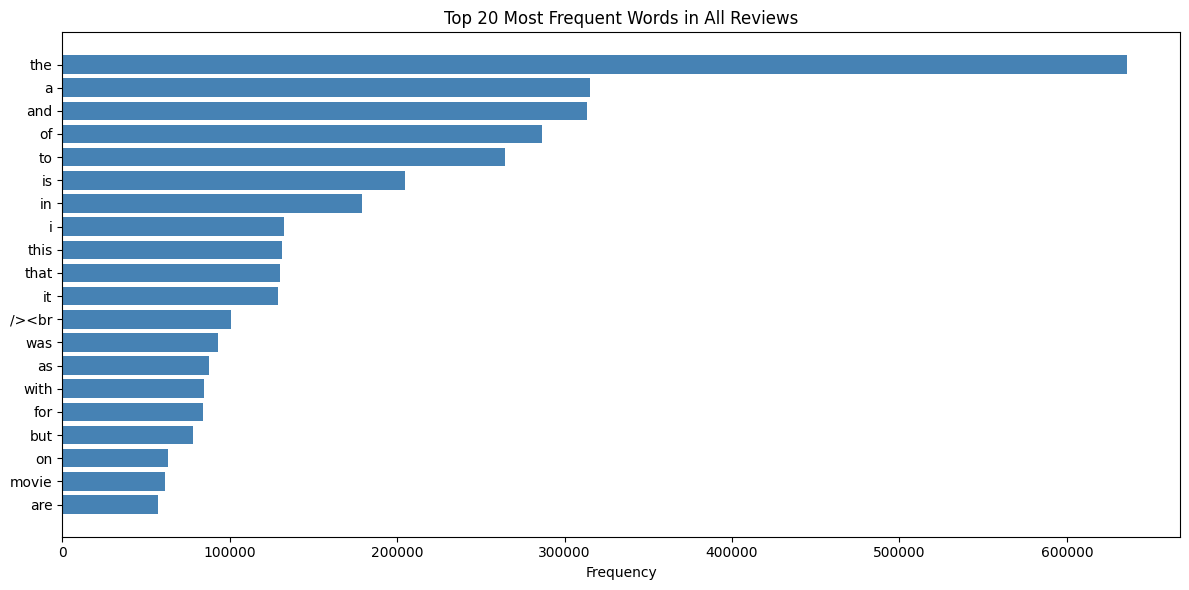

Observation: These are mostly STOP WORDS (common words like "the", "a", "is")


In [27]:
import matplotlib.pyplot as plt

print('\nTOP 20 MOST FREQUENT WORDS (ALL DATA):')
print("-"*70)

top_20 = word_freq.most_common(20)
words = [word for word, count in top_20]
counts = [count for word, count in top_20]

# Print
for i, (word, count) in enumerate(top_20, 1):
    print(f'{i:2}. {word:15} | {count:6,}')

# Visualize
plt.figure(figsize=(12, 6))
plt.barh(words, counts, color='steelblue')
plt.xlabel('Frequency')
plt.title('Top 20 Most Frequent Words in All Reviews')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('Observation: These are mostly STOP WORDS (common words like "the", "a", "is")')

In [28]:
positive_review = df[df['sentiment'] == 'positive']['review']
positive_words = "".join(positive_review).lower().split()
positive_word_freq = Counter(positive_words)
top_20_positive = positive_word_freq.most_common(20)


negative_review = df[df['sentiment'] == 'negative']['review']
negative_words = "".join(negative_review).lower().split()   
negative_word_freq = Counter(negative_words)
top_20_negative = negative_word_freq.most_common(20)

In [29]:
top_20_positive

[('the', 324784),
 ('and', 171338),
 ('a', 160209),
 ('of', 150710),
 ('to', 129529),
 ('is', 108979),
 ('in', 95239),
 ('it', 64482),
 ('that', 63892),
 ('i', 62174),
 ('this', 60571),
 ('as', 49061),
 ('/><br', 48977),
 ('with', 44356),
 ('for', 42647),
 ('was', 42359),
 ('but', 38016),
 ('his', 33314),
 ('on', 31403),
 ('film', 29345)]


SENTIMENT ANALYSIS:
----------------------------------------------------------------------


Text(0, 0.5, 'Words')

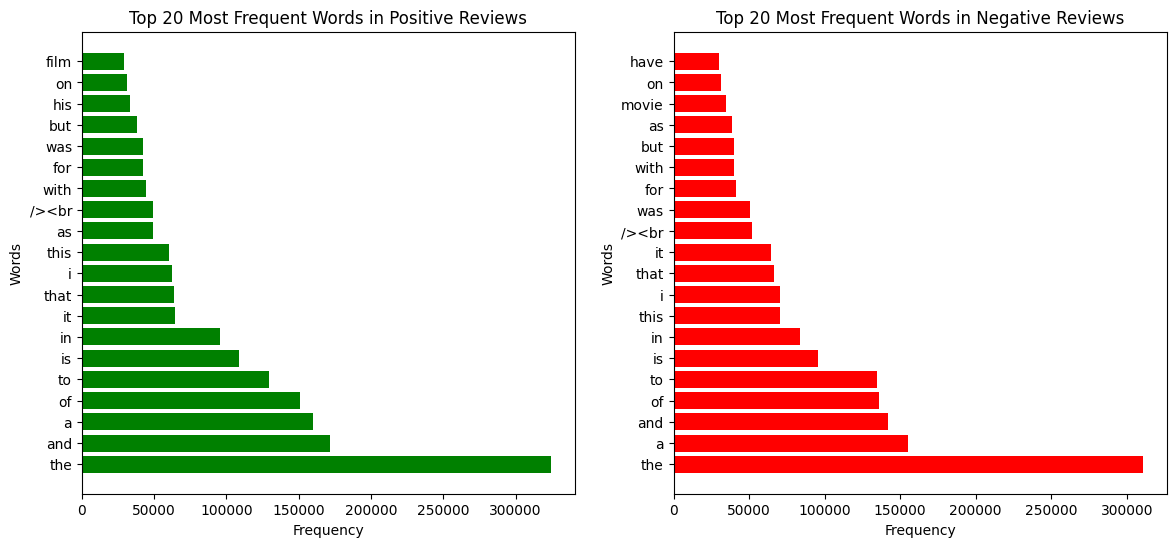

In [30]:
print("\nSENTIMENT ANALYSIS:")
print("-"*70)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Positive words
word_positive = [word for word, count in top_20_positive]
count_positive = [count for word, count in top_20_positive]
axes[0].barh(word_positive, count_positive, color='green')
axes[0].set_title('Top 20 Most Frequent Words in Positive Reviews')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Words')

# Negative words
word_negative = [word for word, count in top_20_negative]
count_negative = [count for word, count in top_20_negative]
axes[1].barh(word_negative, count_negative, color='red')
axes[1].set_title('Top 20 Most Frequent Words in Negative Reviews')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Words')


(np.float64(-0.5), np.float64(399.5), np.float64(299.5), np.float64(-0.5))

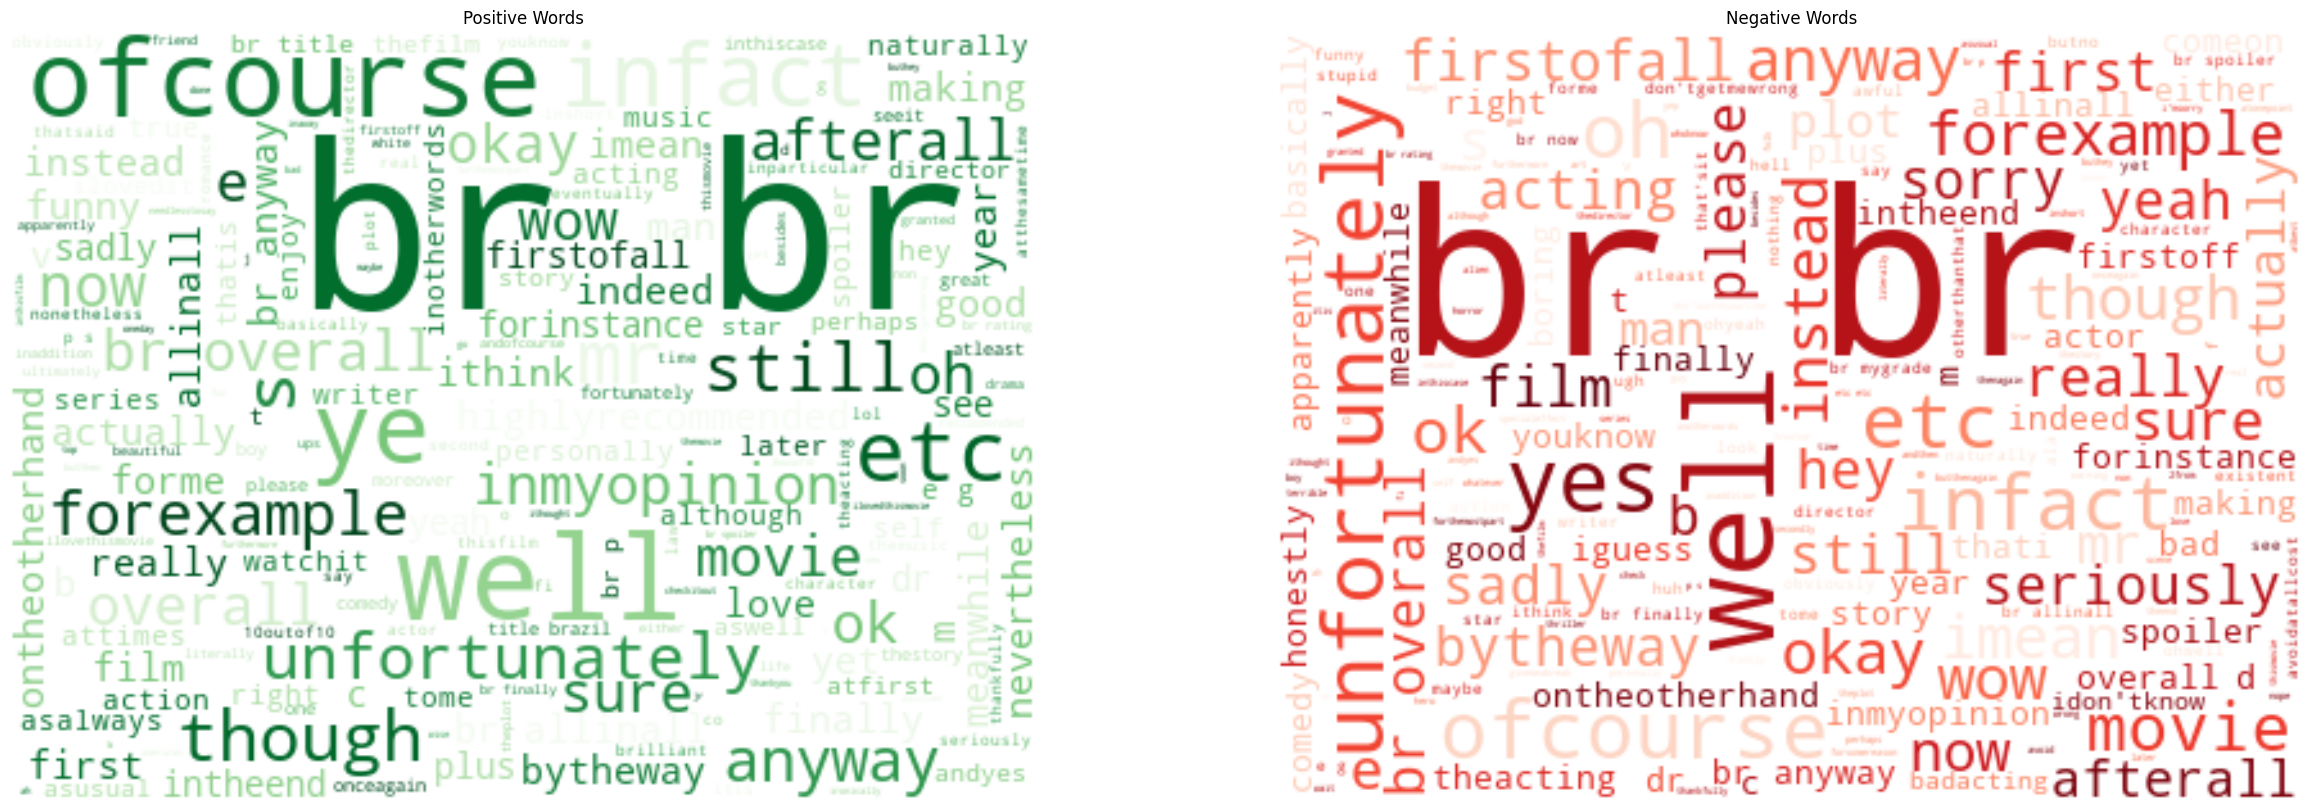

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(30, 10))
# Positive words
Text_positive = ''.join(positive_words)
# Negative words
Text_negative = ''.join(negative_words)

cloud_positive = WordCloud(width=400, height=300, background_color='white', colormap='Greens').generate(Text_positive)
cloud_negative = WordCloud(width=400, height=300, background_color='white', colormap='Reds').generate(Text_negative)

axes[0].imshow(cloud_positive, interpolation='bilinear')
axes[0].set_title('Positive Words')
axes[0].axis('off')

axes[1].imshow(cloud_negative, interpolation='bilinear')
axes[1].set_title('Negative Words')
axes[1].axis('off')

In [32]:
print(f'Count: {len(positive_review)}')
print(f'\nCharacter Length')
print(f'Min: {positive_review.str.len().min()}')
print(f'Max: {positive_review.str.len().max()}')
print(f'Mean: {positive_review.str.len().mean():.2f}')


print(f'word: {len(positive_review.str.split())}')
print(f'Min: {positive_review.str.split().min()}')
print(f'Max: {positive_review.str.split().max()}')

Count: 25000

Character Length
Min: 65
Max: 13704
Mean: 1324.80
word: 25000
Min: ['\x08\x08\x08\x08A', 'Turkish', 'Bath', 'sequence', 'in', 'a', 'film', 'noir', 'located', 'in', 'New', 'York', 'in', 'the', "50's,", 'that', 'must', 'be', 'a', 'hint', 'at', 'something', '!', 'Something', 'that', 'curiously,', 'in', 'all', 'the', 'previous', 'comments,', 'no', 'one', 'has', 'pointed', 'out', ',', 'but', 'seems', 'to', 'me', 'essential', 'to', 'the', 'understanding', 'of', 'this', 'movie', '<br', '/><br', '/>the', 'Turkish', 'Baths', 'sequence:', 'a', 'back', 'street', 'at', 'night,', 'the', 'entrance', 'of', 'a', 'sleazy', 'sauna,', 'and', 'Scalise', 'wrapped', 'in', 'a', 'sheet,', 'getting', 'his', 'thighs', 'massaged.', 'Steve,', 'the', 'masseur', 'is', 'of', 'the', 'young', 'rough', 'boxer', '(', 'Beefcake!)', 'type', ',', 'and', 'another', 'guy,', 'a', 'bodyguard?', 'finishes', 'dressing', 'up.', 'Dixon', 'obviously', 'hates', 'what', 'he', 'sees', 'there', 'and', 'gets', 'rough', 'ri

In [33]:
print(f'count: {len(negative_review)}')
print(f'\nCharacter Length')
print(f'Min: {negative_review.str.len().min()}')
print(f'Max: {negative_review.str.len().max()}')
print(f'Mean: {negative_review.str.len().mean():.2f}')

print(f'word: {len(negative_review.str.split())}')
print(f'Min: {negative_review.str.split().min()}')
print(f'Max: {negative_review.str.split().max()}')


count: 25000

Character Length
Min: 32
Max: 8969
Mean: 1294.06
word: 25000
Min: ['!!!', 'Spoiler', 'alert!!!<br', '/><br', '/>The', 'point', 'is,', 'though,', 'that', 'I', "didn't", 'think', 'this', 'film', 'had', 'an', 'ending', 'TO', 'spoil...', 'I', 'only', 'started', 'watching', 'it', 'in', 'the', 'middle,', 'after', 'Matt', 'had', 'gotten', 'into', "Sarah's", 'body,', 'but', 'then', 'I', 'became', 'fascinated', 'by', 'the', 'bizarreness', 'of', 'the', 'plot,', 'even', 'for', 'a', 'Channel', '5', 'movie...', 'and', "couldn't", 'possibly', 'see', 'how', 'Matt', 'wld', 'end', 'up', 'happy.', 'What', 'about', 'his', 'fiancee?', 'At', 'one', 'stage', 'looked', 'like', 'he', 'was', 'gonna', 'get', 'with', 'his', 'best', 'friend,', 'surely', 'icky', 'and', 'wrong...', 'and', 'then', 'the', 'whole', "'oggi", 'oggi', "oggi'", 'thing', 'does', 'NOT', 'WORK', 'as', 'a', 'touching', 'buddy-buddy', 'catchphrase,', 'tis', 'just', 'ridiculous...', 'so', 'was', 'going', "'surely", 'he', "can't", 

In [34]:
#Grouping by sentiment
from turtle import pos


neg_review = df[df['sentiment'] == 'negative']['review']
pos_review = df[df['sentiment'] == 'positive']['review']

#sentence using regex
neg_sentences = neg_review.str.count(r'[.!?]+').mean()
pos_sentences = pos_review.str.count(r'[.!?]+').mean()  

#grouping by sentiment
pos_char = pos_review.str.len().round(2)
neg_char = neg_review.str.len().round(2)
pos_word = pos_review.str.split().apply(len).round(2)
neg_word = neg_review.str.split().apply(len).round(2)

#Comparison DataFrame
print('\nComparison')
print("-"*70)


comparison_df = pd.DataFrame({'Metric':['count','Avg_length(chars)','Avg_length(words)','avg_sentences'],
                              'Positive':[len(pos_review),pos_char.mean().round(2), pos_word.mean().round(2),pos_sentences.round(2)],
                              'Negative':[len(neg_review),neg_char.mean().round(2), neg_word.mean().round(2),neg_sentences.round(2)]})
print(comparison_df)




Comparison
----------------------------------------------------------------------
              Metric  Positive  Negative
0              count  25000.00  25000.00
1  Avg_length(chars)   1324.80   1294.06
2  Avg_length(words)    232.85    229.46
3      avg_sentences     12.79     13.52


In [35]:
comparison_df['Difference'] = comparison_df['Positive'] - comparison_df['Negative']
print(comparison_df.to_string(index=False))

           Metric  Positive  Negative  Difference
            count  25000.00  25000.00        0.00
Avg_length(chars)   1324.80   1294.06       30.74
Avg_length(words)    232.85    229.46        3.39
    avg_sentences     12.79     13.52       -0.73


C:\Users\GRACE\AppData\Local\Temp\ipykernel_16988\2456996560.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([pos_char, neg_char], labels=['Positive', 'Negative'])
C:\Users\GRACE\AppData\Local\Temp\ipykernel_16988\2456996560.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([pos_word, neg_word], labels=['Positive', 'Negative'])


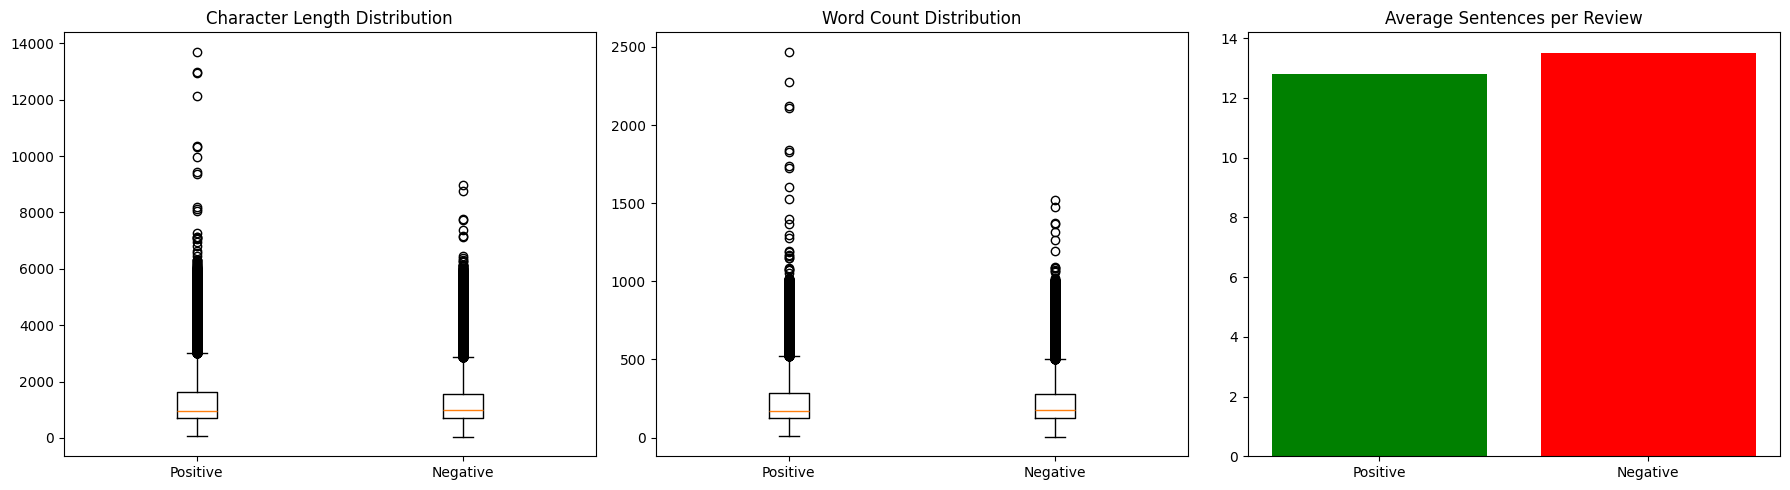

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].boxplot([pos_char, neg_char], labels=['Positive', 'Negative'])
axes[0].set_title('Character Length Distribution')
axes[1].boxplot([pos_word, neg_word], labels=['Positive', 'Negative'])
axes[1].set_title('Word Count Distribution')
axes[2].bar(['Positive', 'Negative'], [pos_sentences, neg_sentences], color=['green', 'red'])
axes[2].set_title('Average Sentences per Review')
plt.tight_layout()
plt.show()

In [37]:
"""print("="*70)
print('PHASE 6: FEATURE ENGINEERING OPPORTUNITIES')
print("="*70)

print('\n1. POTENTIAL FEATURES TO CREATE:')
print("-"*70)

features = {
    'Review Length': {
        'Description': 'Character count of review',
        'Why': 'Longer reviews may indicate more thoughtful opinions',
        'Implementation': 'df["length_chars"] = df["review"].str.len()'
    },
    'Word Count': {
        'Description': 'Number of words in review',
        'Why': 'More words = more detail',
        'Implementation': 'df["word_count"] = df["review"].str.split().str.len()'
    },
    'Sentence Count': {
        'Description': 'Number of sentences',
        'Why': 'Structure indicator',
        'Implementation': 'df["sentence_count"] = df["review"].str.count(r"[.!?]+")'
    },
    'Uppercase Ratio': {
        'Description': '% of uppercase letters',
        'Why': 'Strong emotions use caps (GREAT! BAD!)',
        'Implementation': 'df["uppercase_ratio"] = df["review"].str.count(r"[A-Z]") / df["review"].str.len()'
    },
    'Exclamation Count': {
        'Description': 'Number of ! marks',
        'Why': 'Indicates strong emotion',
        'Implementation': 'df["exclamation_count"] = df["review"].str.count("!")'
    },
    'Question Count': {
        'Description': 'Number of ? marks',
        'Why': 'Rhetorical questions show engagement',
        'Implementation': 'df["question_count"] = df["review"].str.count("\\?")'
    },
}

for feature, info in features.items():
    print(f'\n✓ {feature}')
    print(f'  Description: {info["Description"]}')
    print(f'  Why: {info["Why"]}')
    print(f'  Code: {info["Implementation"]}')"""

'print("="*70)\nprint(\'PHASE 6: FEATURE ENGINEERING OPPORTUNITIES\')\nprint("="*70)\n\nprint(\'\n1. POTENTIAL FEATURES TO CREATE:\')\nprint("-"*70)\n\nfeatures = {\n    \'Review Length\': {\n        \'Description\': \'Character count of review\',\n        \'Why\': \'Longer reviews may indicate more thoughtful opinions\',\n        \'Implementation\': \'df["length_chars"] = df["review"].str.len()\'\n    },\n    \'Word Count\': {\n        \'Description\': \'Number of words in review\',\n        \'Why\': \'More words = more detail\',\n        \'Implementation\': \'df["word_count"] = df["review"].str.split().str.len()\'\n    },\n    \'Sentence Count\': {\n        \'Description\': \'Number of sentences\',\n        \'Why\': \'Structure indicator\',\n        \'Implementation\': \'df["sentence_count"] = df["review"].str.count(r"[.!?]+")\'\n    },\n    \'Uppercase Ratio\': {\n        \'Description\': \'% of uppercase letters\',\n        \'Why\': \'Strong emotions use caps (GREAT! BAD!)\',\n    

# Feature Engineering

In [38]:
df.head(5)

,review,sentiment,word_count,char_count
0,One of the other reviewers has mentioned that ...,positive,307,1761
1,A wonderful little production. <br /><br />The...,positive,162,998
2,I thought this was a wonderful way to spend ti...,positive,166,926
3,Basically there's a family where a little boy ...,negative,138,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230,1317


In [39]:
dff = df.copy()

In [40]:
dff.duplicated().sum()

np.int64(418)

In [41]:
dff.drop_duplicates(inplace=True)

In [42]:
dff.duplicated().sum()

np.int64(0)

In [43]:
#Feature Engineering: Adding review length and word count
dff['length_chars'] = dff['review'].str.len()
dff['word_count'] = dff['review'].str.split().str.len()

#uppercase ratio,exclamation count and question count
dff['uppercase_ratio'] = dff['review'].str.count(r'[A-Z]') / dff['review'].str.len()
dff['exclamation_count'] = dff['review'].str.count('!')
dff['question_count'] = dff['review'].str.count(r'\?')

#avg  length of sentences
dff['avg_length'] = dff['review'].str.len() / dff['word_count']

In [44]:
dff.head()

,review,sentiment,word_count,char_count,length_chars,uppercase_ratio,exclamation_count,question_count,avg_length
0,One of the other reviewers has mentioned that ...,positive,307,1761,1761,0.024418,0,0,5.736156
1,A wonderful little production. <br /><br />The...,positive,162,998,998,0.016032,1,0,6.160494
2,I thought this was a wonderful way to spend ti...,positive,166,926,926,0.024838,0,1,5.578313
3,Basically there's a family where a little boy ...,negative,138,748,748,0.032086,2,0,5.420290
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230,1317,1317,0.025816,0,0,5.726087


In [45]:
#random probe on 4th row, 1st column (review text)
dff.iloc[3,0] 

"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ruins all the film! I expected to see a BOOGEYMAN similar movie, and instead i watched a drama with some meaningless thriller spots.<br /><br />3 out of 10 just for the well playing parents & descent dialogs. As for the shots with Jake: just ignore them."

In [46]:
dff.tail(10)

,review,sentiment,word_count,char_count,length_chars,uppercase_ratio,exclamation_count,question_count,avg_length
49989,I got this one a few weeks ago and love it! It...,positive,173,967,967,0.021717,1,0,5.589595
49990,"Lame, lame, lame!!! A 90-minute cringe-fest th...",negative,128,799,799,0.013767,3,1,6.242188
49992,John Garfield plays a Marine who is blinded by...,positive,170,968,968,0.016529,0,0,5.694118
49993,Robert Colomb has two full-time jobs. He's kno...,negative,479,2717,2717,0.027972,1,0,5.672234
49994,This is your typical junk comedy.<br /><br />T...,negative,134,759,759,0.031621,1,0,5.664179
49995,I thought this movie did a down right good job...,positive,194,1008,1008,0.013889,0,0,5.195876
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,112,642,642,0.029595,0,0,5.732143
49997,I am a Catholic taught in parochial elementary...,negative,230,1280,1280,0.017188,0,0,5.565217
49998,I'm going to have to disagree with the previou...,negative,212,1234,1234,0.018639,0,0,5.820755
49999,No one expects the Star Trek movies to be high...,negative,129,678,678,0.019174,0,0,5.255814


In [47]:
dff.iloc[0,0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [48]:
dff['Review_Cleaned'] = dff['review'].apply(lambda x: contractions.fix(str(x)))

In [49]:
dff.head()

,review,sentiment,word_count,char_count,length_chars,uppercase_ratio,exclamation_count,question_count,avg_length,Review_Cleaned
0,One of the other reviewers has mentioned that ...,positive,307,1761,1761,0.024418,0,0,5.736156,One of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,162,998,998,0.016032,1,0,6.160494,A wonderful little production. <br /><br />The...
2,I thought this was a wonderful way to spend ti...,positive,166,926,926,0.024838,0,1,5.578313,I thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,138,748,748,0.032086,2,0,5.420290,Basically there is a family where a little boy...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230,1317,1317,0.025816,0,0,5.726087,"Petter Mattei's ""Love in the Time of Money"" is..."


In [50]:
dff['Review_Cleaned'] = dff['Review_Cleaned'].str.lower()

In [51]:
dff.head()

,review,sentiment,word_count,char_count,length_chars,uppercase_ratio,exclamation_count,question_count,avg_length,Review_Cleaned
0,One of the other reviewers has mentioned that ...,positive,307,1761,1761,0.024418,0,0,5.736156,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,162,998,998,0.016032,1,0,6.160494,a wonderful little production. <br /><br />the...
2,I thought this was a wonderful way to spend ti...,positive,166,926,926,0.024838,0,1,5.578313,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,138,748,748,0.032086,2,0,5.420290,basically there is a family where a little boy...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230,1317,1317,0.025816,0,0,5.726087,"petter mattei's ""love in the time of money"" is..."


In [52]:
#html tags removal
dff['Review_Cleaned'] = dff['Review_Cleaned'].apply(lambda x: BeautifulSoup(x, "html.parser").get_text())

#url and emaill removal
dff['Review_Cleaned'] = dff['Review_Cleaned'].apply(lambda x: re.sub(r'http\S+|www\S+|https\S+', '', x))

#number removal
dff['Review_Cleaned'] = dff['Review_Cleaned'].apply(lambda x: re.sub(r'\d+', '', x))

#REPEATED WORDS REMOVAL(reducing "good good good" to "good" and "soooo good" to "so good")
dff['Review_Cleaned'] = dff['Review_Cleaned'].apply(lambda x: re.sub(r'\b(\w+)( \1\b)+', r'\1', x))
dff['Review_Cleaned'] = dff['Review_Cleaned'].apply(lambda x: re.sub(r"(\w)\1{2,}", r"\1", x))

#special characters removal
dff['Review_Cleaned'] = dff['Review_Cleaned'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))



In [53]:
dff.head()

,review,sentiment,word_count,char_count,length_chars,uppercase_ratio,exclamation_count,question_count,avg_length,Review_Cleaned
0,One of the other reviewers has mentioned that ...,positive,307,1761,1761,0.024418,0,0,5.736156,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,162,998,998,0.016032,1,0,6.160494,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,positive,166,926,926,0.024838,0,1,5.578313,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,138,748,748,0.032086,2,0,5.420290,basically there is a family where a little boy...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230,1317,1317,0.025816,0,0,5.726087,petter matteis love in the time of money is a ...


In [54]:
#tokenization
dff['Review_Tokens'] = dff['Review_Cleaned'].apply(lambda x: word_tokenize(x))

In [55]:
#removal of stop words
from nltk.corpus import stopwords
nltk.download('stopwords')


stop_words = set(stopwords.words('english'))

#negations
negations = {"not", "no", "never", "nor",'neither','nothing','nobody'}
stop_words = stop_words - negations

dff['Token_Filtered'] = dff['Review_Tokens'].apply(lambda x: [word for word in x if word not in stop_words])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\GRACE\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [56]:
dff.head()

,review,sentiment,word_count,char_count,length_chars,uppercase_ratio,exclamation_count,question_count,avg_length,Review_Cleaned,Review_Tokens,Token_Filtered
0,One of the other reviewers has mentioned that ...,positive,307,1761,1761,0.024418,0,0,5.736156,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione...","[one, reviewers, mentioned, watching, oz, epis..."
1,A wonderful little production. <br /><br />The...,positive,162,998,998,0.016032,1,0,6.160494,a wonderful little production the filming tech...,"[a, wonderful, little, production, the, filmin...","[wonderful, little, production, filming, techn..."
2,I thought this was a wonderful way to spend ti...,positive,166,926,926,0.024838,0,1,5.578313,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,...","[thought, wonderful, way, spend, time, hot, su..."
3,Basically there's a family where a little boy ...,negative,138,748,748,0.032086,2,0,5.420290,basically there is a family where a little boy...,"[basically, there, is, a, family, where, a, li...","[basically, family, little, boy, jake, thinks,..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230,1317,1317,0.025816,0,0,5.726087,petter matteis love in the time of money is a ...,"[petter, matteis, love, in, the, time, of, mon...","[petter, matteis, love, time, money, visually,..."


In [57]:
import nltk
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')       # ← this was missing
nltk.download('omw-1.4')       # ← recommended addition

from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

lemmatizer = WordNetLemmatizer()



import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')  # Optional but recommended — Open Multilingual Wordnet

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\GRACE\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\GRACE\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\GRACE\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\GRACE\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\GRACE\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\GRACE\AppData\Roaming\nltk_dat

True

In [58]:

from nltk.corpus import wordnet
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

def get_wordnet_pos(word):
    """Map POS tag to first character lemmatize() accepts"""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)  # Default to noun if not found

def lemmatize_with_pos(tokens):
    return [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in tokens]

dff['Token_Lemma'] = dff['Token_Filtered'].apply(lemmatize_with_pos)

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\GRACE\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\GRACE\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [59]:
dff['final_review'] = dff['Token_Lemma'].apply(lambda x: ' '.join(x))

In [60]:
dff.head()

,review,sentiment,word_count,char_count,length_chars,uppercase_ratio,exclamation_count,question_count,avg_length,Review_Cleaned,Review_Tokens,Token_Filtered,Token_Lemma,final_review
0,One of the other reviewers has mentioned that ...,positive,307,1761,1761,0.024418,0,0,5.736156,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione...","[one, reviewers, mentioned, watching, oz, epis...","[one, reviewer, mention, watch, oz, episode, h...",one reviewer mention watch oz episode hooked r...
1,A wonderful little production. <br /><br />The...,positive,162,998,998,0.016032,1,0,6.160494,a wonderful little production the filming tech...,"[a, wonderful, little, production, the, filmin...","[wonderful, little, production, filming, techn...","[wonderful, little, production, film, techniqu...",wonderful little production film technique una...
2,I thought this was a wonderful way to spend ti...,positive,166,926,926,0.024838,0,1,5.578313,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,...","[thought, wonderful, way, spend, time, hot, su...","[thought, wonderful, way, spend, time, hot, su...",thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,138,748,748,0.032086,2,0,5.420290,basically there is a family where a little boy...,"[basically, there, is, a, family, where, a, li...","[basically, family, little, boy, jake, thinks,...","[basically, family, little, boy, jake, think, ...",basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230,1317,1317,0.025816,0,0,5.726087,petter matteis love in the time of money is a ...,"[petter, matteis, love, in, the, time, of, mon...","[petter, matteis, love, time, money, visually,...","[petter, matteis, love, time, money, visually,...",petter matteis love time money visually stun f...


In [61]:
#Encooding the sentiment labels to numerical values
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
dff['sentiment_encoded'] = le.fit_transform(dff['sentiment'])

In [62]:
dff.head(5)

,review,sentiment,word_count,char_count,length_chars,uppercase_ratio,exclamation_count,question_count,avg_length,Review_Cleaned,Review_Tokens,Token_Filtered,Token_Lemma,final_review,sentiment_encoded
0,One of the other reviewers has mentioned that ...,positive,307,1761,1761,0.024418,0,0,5.736156,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione...","[one, reviewers, mentioned, watching, oz, epis...","[one, reviewer, mention, watch, oz, episode, h...",one reviewer mention watch oz episode hooked r...,1
1,A wonderful little production. <br /><br />The...,positive,162,998,998,0.016032,1,0,6.160494,a wonderful little production the filming tech...,"[a, wonderful, little, production, the, filmin...","[wonderful, little, production, filming, techn...","[wonderful, little, production, film, techniqu...",wonderful little production film technique una...,1
2,I thought this was a wonderful way to spend ti...,positive,166,926,926,0.024838,0,1,5.578313,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,...","[thought, wonderful, way, spend, time, hot, su...","[thought, wonderful, way, spend, time, hot, su...",thought wonderful way spend time hot summer we...,1
3,Basically there's a family where a little boy ...,negative,138,748,748,0.032086,2,0,5.420290,basically there is a family where a little boy...,"[basically, there, is, a, family, where, a, li...","[basically, family, little, boy, jake, thinks,...","[basically, family, little, boy, jake, think, ...",basically family little boy jake think zombie ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230,1317,1317,0.025816,0,0,5.726087,petter matteis love in the time of money is a ...,"[petter, matteis, love, in, the, time, of, mon...","[petter, matteis, love, time, money, visually,...","[petter, matteis, love, time, money, visually,...",petter matteis love time money visually stun f...,1


## DATA MODELLING

In [63]:
x = dff['final_review']
y = dff['sentiment_encoded']

In [64]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [66]:
x_train_ = X_train_tfidf
x_test_ = X_test_tfidf

Logistic Regression Accuracy: 0.8819
Logistic Regression Recall: 0.8945
Logistic Regression Precision: 0.8733
Logistic Regression F1 Score: 0.8838


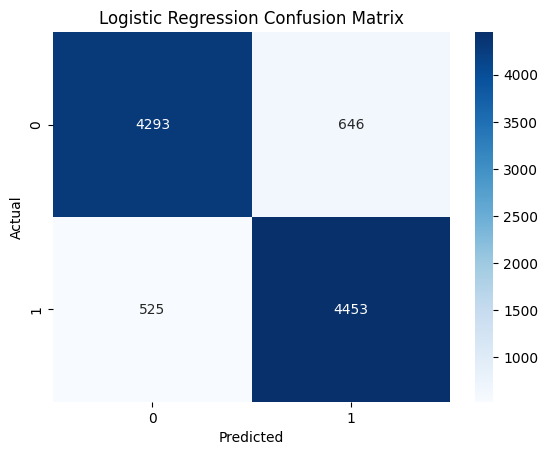

In [ ]:
#logistic regression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression()
model_lr.fit(x_train_, y_train)
y_pred_lr = model_lr.predict(x_test_)
acc_lr = accuracy_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)

print(f'Logistic Regression Accuracy: {acc_lr:.4f}')
print(f'Logistic Regression Recall: {recall_lr:.4f}')
print(f'Logistic Regression Precision: {precision_lr:.4f}') 
print(f'Logistic Regression F1 Score: {f1_lr:.4f}')


sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')    
plt.show()

Naive Bayes Accuracy: 0.8470
Naive Bayes Recall: 0.8534
Naive Bayes Precision: 0.8437
Naive Bayes F1 Score: 0.8485


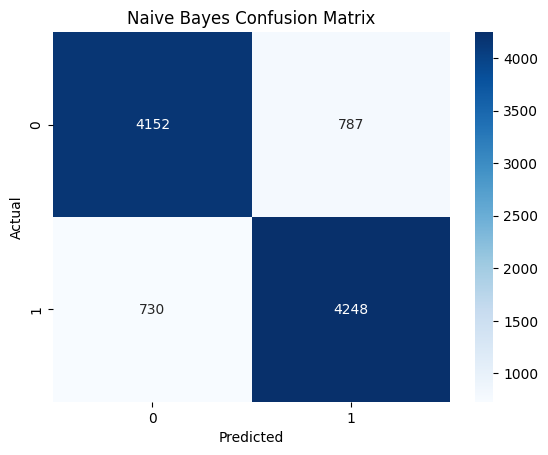

In [95]:
#naive bayes
model_nb = MultinomialNB()
model_nb.fit(x_train_, y_train)
y_pred_nb = model_nb.predict(x_test_)
acc_nb = accuracy_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)

print(f'Naive Bayes Accuracy: {acc_nb:.4f}')
print(f'Naive Bayes Recall: {recall_nb:.4f}')
print(f'Naive Bayes Precision: {precision_nb:.4f}')
print(f'Naive Bayes F1 Score: {f1_nb:.4f}')

sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Blues')
plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Random Forest Accuracy: 0.8356
Random Forest Recall: 0.8305
Random Forest Precision: 0.8402
Random Forest F1 Score: 0.8353


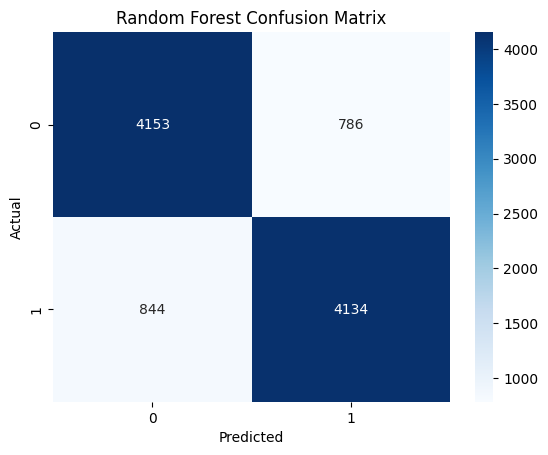

In [97]:
#random forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(x_train_, y_train)
y_pred_rf = model_rf.predict(x_test_)
acc_rf = accuracy_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)

print(f'Random Forest Accuracy: {acc_rf:.4f}')
print(f'Random Forest Recall: {recall_rf:.4f}')
print(f'Random Forest Precision: {precision_rf:.4f}')
print(f'Random Forest F1 Score: {f1_rf:.4f}')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Ridge Classifier Accuracy: 0.8783
Ridge Classifier Recall: 0.8915
Ridge Classifier Precision: 0.8693
Ridge Classifier F1 Score: 0.8803


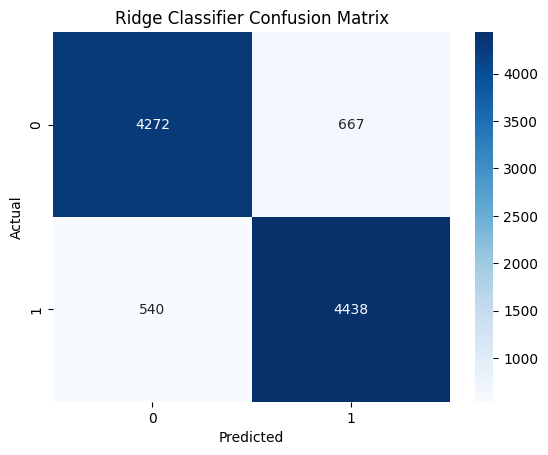

In [ ]:
#Ridge Classifier
model_rc = RidgeClassifier()
model_rc.fit(x_train_, y_train)
y_pred_rc = model_rc.predict(x_test_)
acc_rc = accuracy_score(y_test, y_pred_rc)
recall_rc = recall_score(y_test, y_pred_rc)
f1_rc = f1_score(y_test, y_pred_rc)
precision_rc = precision_score(y_test, y_pred_rc)

print(f'Ridge Classifier Accuracy: {acc_rc:.4f}')
print(f'Ridge Classifier Recall: {recall_rc:.4f}')  
print(f'Ridge Classifier Precision: {precision_rc:.4f}')
print(f'Ridge Classifier F1 Score: {f1_rc:.4f}')

sns.heatmap(confusion_matrix(y_test, y_pred_rc), annot=True, fmt='d', cmap='Blues')
plt.title('Ridge Classifier Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
#creating a DataFrame to summarize the performance metrics of all models

results_Metrics = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Random Forest', 'Ridge Classifier'],
    'Accuracy': [acc_lr, acc_nb, acc_rf, acc_rc],
    'Recall': [recall_lr, recall_nb, recall_rf, recall_rc],
    'Precision': [precision_lr, precision_nb, precision_rf, precision_rc],
    'F1 Score': [f1_lr, f1_nb, f1_rf, f1_rc]
})



In [72]:
print("\nMODEL PERFORMANCE COMPARISON:")
print("-"*70)
print(results_Metrics.to_string(index=False))


MODEL PERFORMANCE COMPARISON:
----------------------------------------------------------------------
              Model  Accuracy   Recall  Precision  F1 Score
Logistic Regression  0.881920 0.894536   0.873308  0.883795
        Naive Bayes  0.847030 0.853355   0.843694  0.848497
      Random Forest  0.835636 0.830454   0.840244  0.835320
   Ridge Classifier  0.878290 0.891523   0.869344  0.880294


In [73]:
#Detailed classification reports for each model

#Logistic Regression
classification_report_lr = classification_report(y_test, y_pred_lr)
print("\nClassification Report for Logistic Regression:")
print(classification_report_lr)

#Naive Bayes
classification_report_nb = classification_report(y_test, y_pred_nb)
print("\nClassification Report for Naive Bayes:")
print(classification_report_nb)

#Random Forest
classification_report_rf = classification_report(y_test, y_pred_rf)
print("\nClassification Report for Random Forest:")
print(classification_report_rf)

#Ridge Classifier
classification_report_rc = classification_report(y_test, y_pred_rc)
print("\nClassification Report for Ridge Classifier:")
print(classification_report_rc)


Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4939
           1       0.87      0.89      0.88      4978

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917


Classification Report for Naive Bayes:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      4939
           1       0.84      0.85      0.85      4978

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917


Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.83      0.84      0.84      4939
           1       0.84      0.83      0.84      4978

    accuracy                           0.84      991

In [74]:
results_Cr = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Random Forest',
                'Ridge Classifier'],
    'Classification Report': [classification_report_lr, classification_report_nb, classification_report_rf, classification_report_rc]
})

In [75]:
print(results_Cr.to_string(index=False))

              Model                                                                                                                                                                                                                                                                                                                          Classification Report
Logistic Regression               precision    recall  f1-score   support\n\n           0       0.89      0.87      0.88      4939\n           1       0.87      0.89      0.88      4978\n\n    accuracy                           0.88      9917\n   macro avg       0.88      0.88      0.88      9917\nweighted avg       0.88      0.88      0.88      9917\n
        Naive Bayes               precision    recall  f1-score   support\n\n           0       0.85      0.84      0.85      4939\n           1       0.84      0.85      0.85      4978\n\n    accuracy                           0.85      9917\n   macro avg       0.85      0.85      0.85   

In [76]:
#cross-validation for logistic regression
from sklearn.model_selection import cross_val_score

cross_val_scores_lr = cross_val_score(model_lr, x_train_, y_train, cv=5, scoring='accuracy')
print("\nCross-Validation Scores for Logistic Regression:")
print(cross_val_scores_lr)
print(f'Average CV Accuracy: {cross_val_scores_lr.mean():.4f}')



Cross-Validation Scores for Logistic Regression:
[0.88339846 0.88188579 0.88314635 0.88390268 0.87923862]
Average CV Accuracy: 0.8823


In [77]:
#most important features for logistic regression
feature_names = vectorizer.get_feature_names_out()
coefficients = model_lr.coef_[0]
feature_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance.sort_values(by='Abs_Coefficient', ascending=False, inplace=True)
top_features = feature_importance.head(20)
print("\nTop 20 Most Important Features for Logistic Regression:")
print(top_features[['Feature', 'Coefficient']].to_string(index=False))


Top 20 Most Important Features for Logistic Regression:
  Feature  Coefficient
      bad   -10.916865
    waste    -8.699513
    awful    -7.669202
    great     7.313512
excellent     6.938755
   boring    -6.174262
 terrible    -5.766654
     poor    -5.730901
  nothing    -5.324593
     dull    -5.283527
  perfect     5.225315
 horrible    -5.092072
     best     4.899364
    amaze     4.896205
wonderful     4.793391
   poorly    -4.776852
    fails    -4.760903
     love     4.726937
  suppose    -4.649147
 favorite     4.543587


In [78]:
#Grouping the features into positive and negative based on coefficient sign
feature_importance['Sentiment'] = feature_importance['Coefficient'].apply(lambda x: 'Positive' if x > 0 else 'Negative')
print("\nFeature Importance with Sentiment:")
print(feature_importance[['Feature', 'Coefficient', 'Sentiment']].head(20).to_string(index=False))


Feature Importance with Sentiment:
  Feature  Coefficient Sentiment
      bad   -10.916865  Negative
    waste    -8.699513  Negative
    awful    -7.669202  Negative
    great     7.313512  Positive
excellent     6.938755  Positive
   boring    -6.174262  Negative
 terrible    -5.766654  Negative
     poor    -5.730901  Negative
  nothing    -5.324593  Negative
     dull    -5.283527  Negative
  perfect     5.225315  Positive
 horrible    -5.092072  Negative
     best     4.899364  Positive
    amaze     4.896205  Positive
wonderful     4.793391  Positive
   poorly    -4.776852  Negative
    fails    -4.760903  Negative
     love     4.726937  Positive
  suppose    -4.649147  Negative
 favorite     4.543587  Positive


In [79]:
feature_importance.head(10)

,Feature,Coefficient,Abs_Coefficient,Sentiment
326,bad,-10.916865,10.916865,Negative
4851,waste,-8.699513,8.699513,Negative
316,awful,-7.669202,7.669202,Negative
1963,great,7.313512,7.313512,Positive
1562,excellent,6.938755,6.938755,Positive
490,boring,-6.174262,6.174262,Negative
4476,terrible,-5.766654,5.766654,Negative
3362,poor,-5.730901,5.730901,Negative
3065,nothing,-5.324593,5.324593,Negative
1375,dull,-5.283527,5.283527,Negative


In [80]:
#predicting on new reviews
new_reviews = [
    "I absolutely hated this movie. The plot was bad and the acting was not superb.",
    "This was the worst film I've ever seen. It was a complete waste of time.",
    "i  do not like this movie.."
]

In [81]:
new_reviews_tfidf = vectorizer.transform(new_reviews)
new_predictions = model_lr.predict(new_reviews_tfidf)
print("\nPredictions for New Reviews:")
for review, pred in zip(new_reviews, new_predictions):
    sentiment = 'Positive' if pred == 1 else 'Negative'
    print(f'Review: "{review}"\nPredicted Sentiment: {sentiment}\n')    


Predictions for New Reviews:
Review: "I absolutely hated this movie. The plot was bad and the acting was not superb."
Predicted Sentiment: Negative

Review: "This was the worst film I've ever seen. It was a complete waste of time."
Predicted Sentiment: Negative

Review: "i  do not like this movie.."
Predicted Sentiment: Negative



# IMDB Movie Review Sentiment Analysis — Summary

## Overview
A binary sentiment classifier that labels IMDB movie reviews as **positive** or **negative**, built on the 50,000-review IMDB dataset. The pipeline runs from raw text through cleaning, TF-IDF vectorization, and four classical ML models.

## Dataset
- **Size:** 50,000 reviews, reduced to about 49,582 after removing 418 duplicates.
- **Balance:** Perfectly balanced, with 25,000 positive and 25,000 negative.
- **Nulls:** None.
- **Implication:** Because classes are balanced, accuracy is trustworthy and F1 is the safe headline metric.

## Pipeline
1. **EDA:** class distribution, review length, word counts, top words, per-sentiment word clouds, positive vs. negative comparison.
2. **Feature engineering:** review length, word count, uppercase ratio, exclamation and question counts, average word length.
3. **Text cleaning:** expand contractions, lowercase, strip HTML / URLs / numbers, collapse repeated words and characters, remove special characters.
4. **Tokenization & normalization:** word tokenize, remove stopwords (**negations preserved**: not, no, never, etc.), POS-aware lemmatization.
5. **Vectorization:** TF-IDF with `max_features=5000`.
6. **Modeling:** 80/20 train/test split, `random_state=42`.

## Models & Results

| Model | Accuracy | Recall | Precision | F1 |
|---|---|---|---|---|
| **Logistic Regression** | **0.8819** | **0.8945** | **0.8733** | **0.8838** |
| Ridge Classifier | 0.8783 | 0.8915 | 0.8693 | 0.8803 |
| Naive Bayes | 0.8470 | 0.8534 | 0.8437 | 0.8485 |
| Random Forest | 0.8356 | 0.8305 | 0.8402 | 0.8353 |

**Winner: Logistic Regression**, best on every metric, with a 5-fold CV accuracy that confirms it isn't overfitting. Top TF-IDF coefficients align with intuition (positive: *great, excellent, best*; negative: *worst, bad, boring*).

## Metric Guidance (for this project)
- **Headline metric: F1**, the convention for text classification and robust if the class balance ever shifts.
- **Report accuracy alongside it**, valid here because data is balanced, and it's the most intuitive number to communicate.
- Standalone precision or recall isn't needed, since a false positive and a false negative are equally costly in sentiment labeling.

## What's Next — Improvement Roadmap

### 1. Features (biggest quick win)
- **Add n-grams:** `TfidfVectorizer(ngram_range=(1,2))`. Bigrams capture phrases like *"not good"* and *"waste of time"* that unigrams miss. This usually gives the largest bump for the least effort.
- **Raise the feature cap:** try `max_features=10000` to `20000` (or remove it) and compare.
- **Tune `min_df` and `max_df`** to drop noise and overly common terms.

### 2. Model tuning
- **GridSearchCV or RandomizedSearchCV** on Logistic Regression (`C`, penalty), and try **LinearSVC**, which often edges out LR on TF-IDF text.
- **Run cross-validation for all models**, not just Logistic Regression, so comparisons are apples-to-apples.

### 3. Stronger models (for a real jump)
- **Transformer embeddings** (e.g. DistilBERT/BERT fine-tuning) typically push IMDB accuracy to about 92 to 94%. Bigger lift, more compute.
- Or a lighter middle step: **Word2Vec / GloVe averaged embeddings** into the same classical models.

### 4. Error analysis
- Pull the misclassified reviews and read them, looking for sarcasm, mixed sentiment, and negation failures. Your new-review test (*"do not like this movie"*) is exactly the kind of edge case to inspect.
- Consider **threshold tuning** on predicted probabilities if you later care more about one class.

### 5. Reproducibility & deployment
- **Wrap cleaning, TF-IDF, and model into a single `sklearn.Pipeline`** so training and inference use identical steps.
- **Persist the model** with `joblib.dump` and load it for predictions instead of retraining.
- Add a small **`predict_sentiment(text)`** helper that runs the full cleaning pipeline on raw input. Right now new reviews skip the cleaning steps applied during training, which is worth aligning.

### 6. Reporting
- Add **macro-averaged F1** (`average='macro'`) for a metric that weights both classes evenly.
- Save a comparison bar chart of all four models across the four metrics for a clear visual summary.

### Priority order
1. N-grams in TF-IDF
2. Align new-review predictions with the training cleaning pipeline
3. Hyperparameter tuning and LinearSVC
4. Cross-validate all models
5. (Stretch) Transformer fine-tuning